In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collaborative import load_ratings, build_user_item_matrix, user_based_cf, item_based_cf
from content_based import load_movies, build_content_matrix, content_based_recs
from hybrid import train_svd, svd_recommend, hybrid_recommend, popularity_fallback

In [3]:
# -- 1. LOAD DATA
def load_ratings_csv(path):
    df = pd.read_csv(path)
    df.columns = ['userId', 'movieId', 'rating', 'timestamp']
    print(f'Loaded {len(df):,} ratings')
    return df

def load_movies_csv(path):
    df = pd.read_csv(path)
    df.columns = ['movieId', 'title', 'genres']
    df['genres'] = df['genres'].fillna('').astype(str)
    df['genres_clean'] = df['genres'].str.replace('|', ' ', regex=False)
    return df

ratings = load_ratings_csv('data/raw/ratings.csv')
movies  = load_movies_csv('data/raw/movies.csv')
print(ratings.head())
print(movies.head())

Loaded 32,000,204 ratings
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  \
0  Adventure|Animation|Children|Comedy|Fantasy   
1                   Adventure|Children|Fantasy   
2                               Comedy|Romance   
3                         Comedy|Drama|Romance   
4                                       Comedy   

                                  genres_clean  
0  Adventure Animation Children Comedy Fantasy  
1                   Adventure Children Fantasy

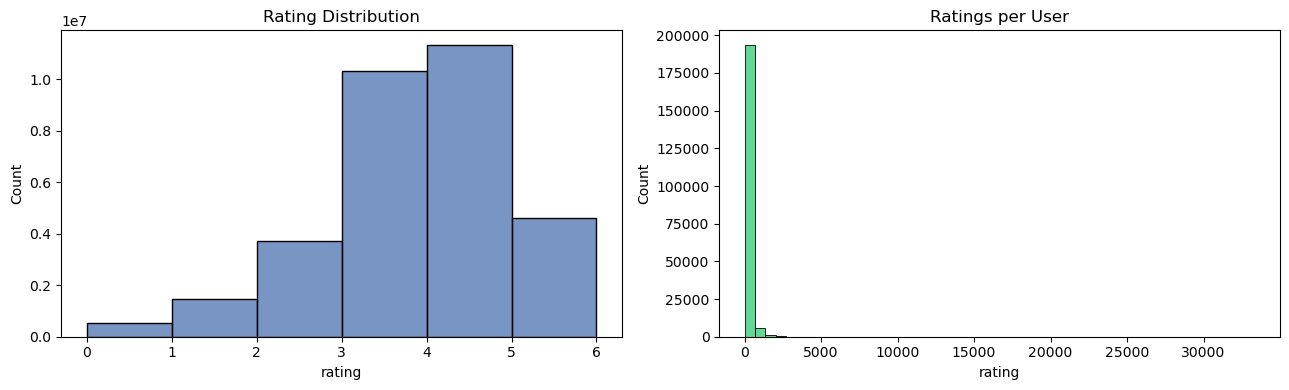

In [4]:
# -- 2. EDA
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ratings['rating'], bins=5, discrete=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Rating Distribution')
ratings_per_user = ratings.groupby('userId')['rating'].count()
sns.histplot(ratings_per_user, bins=50, ax=axes[1], color='#2ecc71')
axes[1].set_title('Ratings per User')
plt.tight_layout()
plt.savefig('outputs/eda.png', dpi=150)
plt.show()

In [5]:
# -- 3. USER-ITEM MATRIX (sampled for memory)
import numpy as np

# Sample 2000 users to keep matrix manageable
sample_users = ratings['userId'].drop_duplicates().sample(2000, random_state=42)
ratings_sample = ratings[ratings['userId'].isin(sample_users)].copy()

matrix = build_user_item_matrix(ratings_sample)
print(matrix.shape)

Matrix shape: (2000, 17338) | Sparsity: 99.08%
(2000, 17338)


In [6]:
# -- 4. USER-BASED CF
user_id = ratings_sample['userId'].iloc[0]
cf_recs = user_based_cf(matrix, user_id=user_id, top_n=10)
cf_titles = movies[movies['movieId'].isin(cf_recs)][['movieId', 'title']]
print(f'User-Based CF Recs for User {user_id}:')
print(cf_titles.to_string(index=False))

User-Based CF Recs for User 102:
 movieId                                       title
     232 Eat Drink Man Woman (Yin shi nan nu) (1994)
    1446                        Kolya (Kolja) (1996)
    1449                  Waiting for Guffman (1996)
    2018                                Bambi (1942)
    2117          1984 (Nineteen Eighty-Four) (1984)
    2313                    Elephant Man, The (1980)
    2841                       Stir of Echoes (1999)
    3505                           No Way Out (1987)
    3510                            Frequency (2000)
    7327                              Persona (1966)


In [7]:
# -- 5. CONTENT-BASED (sampled for memory)
movies_sample = movies.sample(2000, random_state=42).reset_index(drop=True)
content_sim = build_content_matrix(movies_sample)

movie_id = movies_sample['movieId'].iloc[0]
cb_recs  = content_based_recs(movie_id, movies_sample, content_sim, top_n=10)
cb_titles = movies_sample[movies_sample['movieId'].isin(cb_recs)][['movieId', 'title', 'genres']]
print(f'Content-Based Recs for Movie {movie_id}:')
print(cb_titles.to_string(index=False))

Content similarity matrix: (2000, 2000)
Content-Based Recs for Movie 120510:
 movieId                                                    title         genres
  188507                                        Runway Cop (2012) Comedy|Romance
  161242                                 Love in the Rough (1930) Comedy|Romance
  266872                           Every Time a Bell Rings (2021) Comedy|Romance
    3394                                        Blind Date (1987) Comedy|Romance
  223826                         The Broken Hearts Gallery (2020) Comedy|Romance
  134728                                   Slightly French (1949) Comedy|Romance
   92925                                    Love Trap, The (1929) Comedy|Romance
  141271                             Having Wonderful Time (1938) Comedy|Romance
   57179 Mostly Unfabulous Social Life of Ethan Green, The (2005) Comedy|Romance
  228663                              Love The Way You Are (2019) Comedy|Romance


In [8]:
# -- 6. SVD MODEL (sampled for memory)
ratings_svd = ratings[ratings['userId'].isin(sample_users)].copy()

svd_model, data = train_svd(ratings_svd)
all_movies      = ratings_svd['movieId'].unique().tolist()
seen_by_user    = ratings_svd[ratings_svd['userId'] == user_id]['movieId'].tolist()
svd_recs        = svd_recommend(svd_model, user_id, all_movies, seen_by_user, top_n=10)
svd_titles      = movies[movies['movieId'].isin(svd_recs)][['movieId', 'title']]
print(f'SVD Recs for User {user_id}:')
print(svd_titles.to_string(index=False))

Running 5-fold cross-validation on SVD...
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8789  0.8803  0.8831  0.8758  0.8733  0.8783  0.0034  
MAE (testset)     0.6666  0.6661  0.6670  0.6638  0.6598  0.6647  0.0027  
Fit time          1.98    2.06    2.02    2.16    1.95    2.04    0.07    
Test time         0.51    0.36    0.42    0.34    0.38    0.40    0.06    
SVD model trained on full dataset.
SVD Recs for User 102:
 movieId                                                title
     260            Star Wars: Episode IV - A New Hope (1977)
     296                                  Pulp Fiction (1994)
     858                                Godfather, The (1972)
    1211     Wings of Desire (Himmel über Berlin, Der) (1987)
    1248                                 Touch of Evil (1958)
    1258                                  Shining, The (1980)
    3022                             

In [9]:
# -- 7. HYBRID
hybrid_recs = hybrid_recommend(user_id, ratings_sample, svd_model,
                                content_sim, 
                                movies_sample['movieId'].tolist(), top_n=10)
hybrid_titles = movies_sample[movies_sample['movieId'].isin(hybrid_recs)][['movieId', 'title']]
print(f'Hybrid Recs for User {user_id}:')
print(hybrid_titles.to_string(index=False))

Hybrid Recs for User 102:
 movieId                                                             title
    1834                                      Spanish Prisoner, The (1997)
    2176                                                       Rope (1948)
    1150 Return of Martin Guerre, The (Retour de Martin Guerre, Le) (1982)
    2819            Three Days of the Condor (3 Days of the Condor) (1975)
    8973                          Bad Education (La mala educación) (2004)
    2936                                         Sullivan's Travels (1941)
   26662                Kiki's Delivery Service (Majo no takkyûbin) (1989)
    7072                                                 Stagecoach (1939)
    1104                                  Streetcar Named Desire, A (1951)
  112552                                                   Whiplash (2014)


In [10]:
# -- 8. COLD START FALLBACK
fallback = popularity_fallback(ratings, top_n=10)
fallback_titles = movies[movies['movieId'].isin(fallback)][['movieId', 'title']]
print('Popularity Fallback (New User):')
print(fallback_titles.to_string(index=False))

Popularity Fallback (New User):
 movieId                            title
     318 Shawshank Redemption, The (1994)
     858            Godfather, The (1972)
  159817              Planet Earth (2006)
  170705          Band of Brothers (2001)
  171011           Planet Earth II (2016)
  171495                           Cosmos
  179135            Blue Planet II (2017)
  198185                Twin Peaks (1989)
  202439                  Parasite (2019)
  220528          Twelve Angry Men (1954)


In [11]:
# -- 9. SAVE OUTPUT
hybrid_titles.to_csv('outputs/recommendations_sample.csv', index=False)
print('Sample recommendations saved to outputs/recommendations_sample.csv')

Sample recommendations saved to outputs/recommendations_sample.csv
